# APPNP Embeddings for Contig Binning

An MLP encoder over adjacency-row, TNF, and coverage features, followed by personalized PageRank propagation and RepBin-like marker cannot-link training.

This notebook runs the test dataset 10 times with different seeds, records all metrics for every run, prints min/max/mean/std, and plots mean metric values with standard-deviation error bars. Labels are used only after clustering to evaluate the bins. The shared loader uses `agtools.assemblers.spades.get_contig_graph` to load `tests/data/assembly_graph_with_scaffolds.gfa`, `tests/data/contigs.fasta`, and `tests/data/contigs.paths`. Node features follow the requested RepBin-like representation: the contig adjacency-matrix row plus 136 reverse-complement-collapsed normalized tetranucleotide frequencies plus z-scored `log1p` coverage parsed from SPAdes contig IDs. The number of clusters is estimated from `contigs.fasta.markers`.

If dependencies are missing in a fresh environment, run:

```python
%pip install agtools torch scikit-learn biopython numpy pandas matplotlib
```

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from graph_binning_common import *

DATA_DIR = REPO_ROOT / 'tests' / 'data'
SEED = 7
N_RUNS = 10
set_seed(SEED)


In [2]:
data = load_spades_dataset(DATA_DIR)
print_dataset_summary(data)

features = data['features']
adjacency = data['adjacency']
marker_pairs = data['marker_pairs']
labels = data['labels']
label_names = data['label_names']

# RepBin derives the expected number of bins from marker-gene constraints.
# Ground truth is used only after clustering to evaluate the predicted bins.
N_CLUSTERS = data['marker_cluster_count']
print(f'k for clustering from marker genes: {N_CLUSTERS}')
print(f'marker cannot-link pairs: {len(marker_pairs)}')
print(data['feature_names'][:3], '...', data['feature_names'][-3:])


contigs: 509
edges: 1033
features: 646 (509 adjacency + 136 TNF + coverage)
marker sets: 91
marker-derived k: 5
Acetobacter_pasteurianus: 118
Aeromonas_veronii: 72
Amycolatopsis_mediterranei: 105
Arthrobacter_arilaitensis: 195
Azorhizobium_caulinodans: 19
k for clustering from marker genes: 5
marker cannot-link pairs: 1820
['adjacency_to_node_0', 'adjacency_to_node_1', 'adjacency_to_node_2'] ... ['TGCA', 'TTAA', 'log1p_coverage_zscore']


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

METHOD_NAME = 'APPNP'

class APPNPEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=96, embedding_dim=32, dropout=0.25, alpha=0.1, propagation_steps=10):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, embedding_dim)
        self.dropout = dropout
        self.alpha = alpha
        self.propagation_steps = propagation_steps

    def forward(self, x, adjacency):
        h = F.relu(self.lin1(x))
        h = F.dropout(h, p=self.dropout, training=self.training)
        z = self.lin2(h)
        initial = z
        a_hat = normalized_adjacency(adjacency.numpy(), mode='symmetric')
        a_hat = torch.tensor(a_hat, dtype=torch.float32, device=x.device)
        for _ in range(self.propagation_steps):
            z = (1 - self.alpha) * (a_hat @ z) + self.alpha * initial
        return F.normalize(z, p=2, dim=1)

def run_once(seed):
    set_seed(seed)
    model = APPNPEncoder(features.shape[1])
    embeddings, history = train_torch_graph_autoencoder(model, features, adjacency, marker_pairs)
    predictions, metrics = run_kmeans(embeddings, labels, seed=seed, n_clusters=N_CLUSTERS)
    metrics['epochs'] = history[-1]['epoch']
    metrics['loss'] = history[-1]['loss']
    return metrics


run 01 seed=7: precision=0.9411, recall=0.8330, f1=0.8837, ari=0.7292, nmi=0.8212
run 02 seed=8: precision=0.9430, recall=0.8448, f1=0.8912, ari=0.7431, nmi=0.8299
run 03 seed=9: precision=0.9411, recall=0.8310, f1=0.8826, ari=0.7280, nmi=0.8181
run 04 seed=10: precision=0.9411, recall=0.8330, f1=0.8837, ari=0.7296, nmi=0.8186
run 05 seed=11: precision=0.9430, recall=0.8507, f1=0.8945, ari=0.7480, nmi=0.8301
run 06 seed=12: precision=0.9430, recall=0.8389, f1=0.8879, ari=0.7370, nmi=0.8267
run 07 seed=13: precision=0.9430, recall=0.8389, f1=0.8879, ari=0.7377, nmi=0.8282
run 08 seed=14: precision=0.9430, recall=0.8310, f1=0.8835, ari=0.7306, nmi=0.8247
run 09 seed=15: precision=0.9430, recall=0.8507, f1=0.8945, ari=0.7480, nmi=0.8301
run 10 seed=16: precision=0.9411, recall=0.8271, f1=0.8804, ari=0.7250, nmi=0.8171


,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,1,7,0.941061,0.833006,0.883743,0.729171,0.821202,5,5,0.803786,323,1.069752
1,2,8,0.943026,0.844794,0.891211,0.743122,0.829906,5,5,0.811968,222,1.071352
2,3,9,0.941061,0.831041,0.882636,0.728030,0.818067,5,5,0.801613,261,1.070699
3,4,10,0.941061,0.833006,0.883743,0.729604,0.818551,5,5,0.802930,254,1.070394
4,5,11,0.943026,0.850688,0.894480,0.747999,0.830058,5,5,0.815878,288,1.070329
5,6,12,0.943026,0.838900,0.887920,0.736991,0.826656,5,5,0.807828,244,1.070596
6,7,13,0.943026,0.838900,0.887920,0.737703,0.828237,5,5,0.808010,238,1.070644
7,8,14,0.943026,0.831041,0.883499,0.730603,0.824688,5,5,0.802552,224,1.071010
8,9,15,0.943026,0.850688,0.894480,0.747999,0.830058,5,5,0.815878,245,1.071214
9,10,16,0.941061,0.827112,0.880415,0.725025,0.817143,5,5,0.798989,342,1.070435


,min,max,mean,std
precision,0.941061,0.943026,0.942240,0.001015
recall,0.827112,0.850688,0.837917,0.008399
f1,0.880415,0.894480,0.887005,0.005025
ari,0.725025,0.747999,0.735625,0.008445
nmi,0.817143,0.830058,0.824457,0.005285
aligned_macro_f1,0.798989,0.815878,0.806943,0.005999


<Axes: title={'center': 'APPNP: mean metrics over 10 runs'}, ylabel='score'>

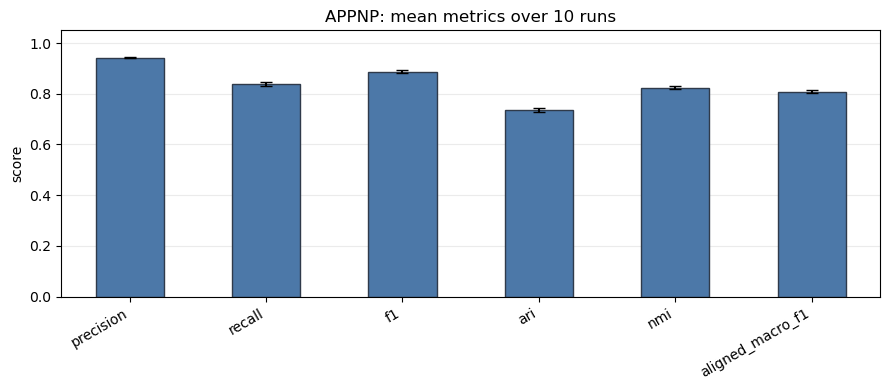

In [4]:
results = run_repeated_experiment(run_once, n_runs=N_RUNS, seed=SEED)
summary = summarize_metric_table(results)

display(results)
display(summary)
plot_metric_bars(summary, title=f'{METHOD_NAME}: mean metrics over {N_RUNS} runs')


## Assembly graph coloured by predicted bin

This plot reruns the method once on the original test graph using `SEED`, captures that method's KMeans bin assignments, and colours contigs in the igraph assembly graph by the predicted bin.

{'precision': 0.9430255402750491, 'recall': 0.8388998035363457, 'f1': 0.8879204094761763, 'ari': 0.7369912207004937, 'nmi': 0.8266559009234855, 'n_bins_predicted': 5, 'n_true_bins': 5, 'aligned_macro_f1': 0.8078283971590727, 'epochs': 323, 'loss': 1.0696884393692017}
APPNP: assembly graph coloured by predicted bin
bin 0: 103 contigs
bin 1: 115 contigs
bin 2: 121 contigs
bin 3: 71 contigs
bin 4: 99 contigs


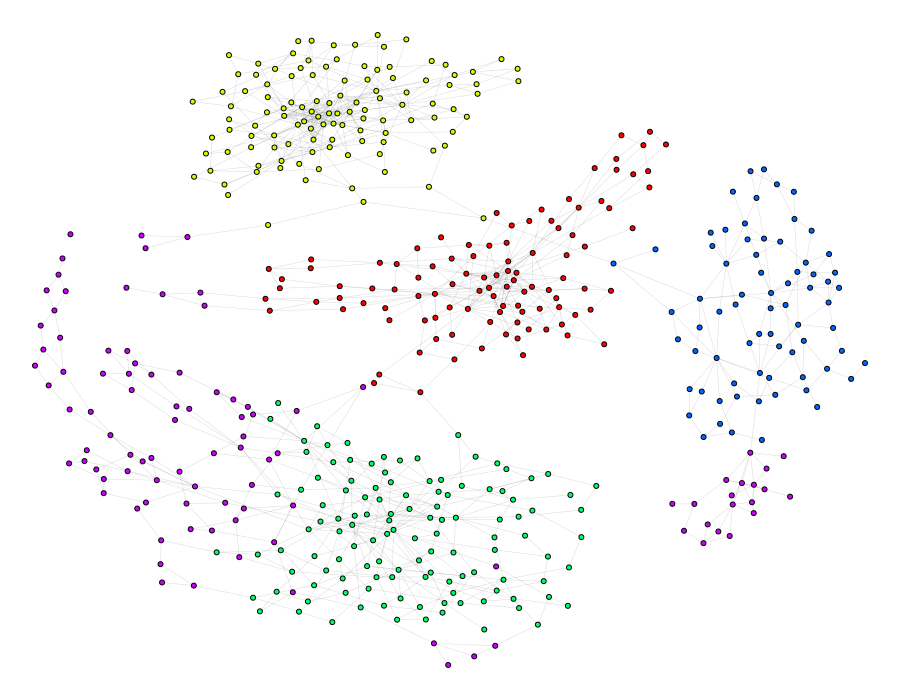

In [5]:
_visual_predictions = None
_original_run_kmeans = run_kmeans

def _capture_run_kmeans(embeddings, labels, seed=7, n_clusters=None):
    global _visual_predictions
    predictions, metrics = _original_run_kmeans(embeddings, labels, seed=seed, n_clusters=n_clusters)
    _visual_predictions = predictions
    return predictions, metrics

run_kmeans = _capture_run_kmeans
try:
    visual_metrics = run_once(SEED)
finally:
    run_kmeans = _original_run_kmeans

print(visual_metrics)
plot_assembly_graph_bins(
    data,
    bins=_visual_predictions,
    title=f'{METHOD_NAME}: assembly graph coloured by predicted bin',
)


## Graph corruption / ablation study

This section reruns the same method under five graph conditions: original assembly graph, random edge removal, random edge addition, coverage-similarity edges added, and short contigs removed. Each condition is run with the same 10 seeds, then metrics are summarized and plotted with standard-deviation error bars.

ablation: original assembly graph
ablation: random edge removal
ablation: random edge addition
ablation: coverage-similarity edges added
ablation: short contigs removed


,ablation,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,original assembly graph,1,7,0.941061,0.833006,0.883743,0.729171,0.821202,5,5,0.803786,323,1.069818
1,original assembly graph,2,8,0.943026,0.834971,0.885715,0.734328,0.827200,5,5,0.805392,222,1.071275
2,original assembly graph,3,9,0.944990,0.833006,0.885471,0.735432,0.827552,5,5,0.803536,209,1.071267
3,original assembly graph,4,10,0.929273,0.821218,0.871911,0.706801,0.804419,5,5,0.794717,282,1.071585
4,original assembly graph,5,11,0.943026,0.842829,0.890117,0.740472,0.827729,5,5,0.810491,288,1.069940
5,original assembly graph,6,12,0.943026,0.836935,0.886819,0.735322,0.826142,5,5,0.806504,252,1.070517
6,original assembly graph,7,13,0.943026,0.838900,0.887920,0.737703,0.828237,5,5,0.808010,238,1.070644
7,original assembly graph,8,14,0.943026,0.831041,0.883499,0.730603,0.824688,5,5,0.802552,224,1.071016
8,original assembly graph,9,15,0.943026,0.850688,0.894480,0.747999,0.830058,5,5,0.815878,245,1.071236
9,original assembly graph,10,16,0.943026,0.844794,0.891211,0.742283,0.828288,5,5,0.811830,298,1.071151


precision                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.929273  0.944990  0.941650  0.004446   
random edge removal              0.909627  0.923379  0.916699  0.004364   
random edge addition             0.897839  0.909627  0.902554  0.003490   
coverage-similarity edges added  0.819253  0.846758  0.836935  0.007967   
short contigs removed            0.911111  0.933333  0.926000  0.009195   

                                   recall                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.821218  0.850688  0.836739  0.008203   
random edge removal              0.783890  0.805501  0.794106  0.005988   
random edge addition             0.791749  0.809430  0.798625  0.006499   
coverage-similarity edges added  0.770138  0.813360  0.789784  0.013032   
short contigs removed            0.806667  0.831111  0.820222  0.010394   

                                       f1            ...       ari            \
                                      min       max  ...      mean       std   
ablation                                             ...                       
original assembly graph          0.871911  0.894480  ...  0.734011  0.011049   
random edge removal              0.843770  0.859568  ...  0.668096  0.010200   
random edge addition             0.842325  0.856608  ...  0.650243  0.008135   
coverage-similarity edges added  0.793937  0.827832  ...  0.570202  0.018065   
short contigs removed            0.855714  0.879261  ...  0.712492  0.019727   

                                      nmi                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.804419  0.830058  0.824552  0.007476   
random edge removal              0.753558  0.787170  0.773110  0.009656   
random edge addition             0.710871  0.738366  0.720638  0.008213   
coverage-similarity edges added  0.572676  0.631151  0.605847  0.015737   
short contigs removed            0.773641  0.813610  0.800527  0.015486   

                                aligned_macro_f1                                
                                             min       max      mean       std  
ablation                                                                        
original assembly graph                 0.794717  0.815878  0.806270  0.005829  
random edge removal                     0.768835  0.783211  0.775161  0.004344  
random edge addition                    0.763740  0.776653  0.769210  0.004568  
coverage-similarity edges added         0.719025  0.759460  0.734741  0.012574  
short contigs removed                   0.779947  0.799046  0.790982  0.007975  

[5 rows x 24 columns]

<Axes: title={'center': 'APPNP: graph corruption / ablation study'}, xlabel='ablation', ylabel='score'>

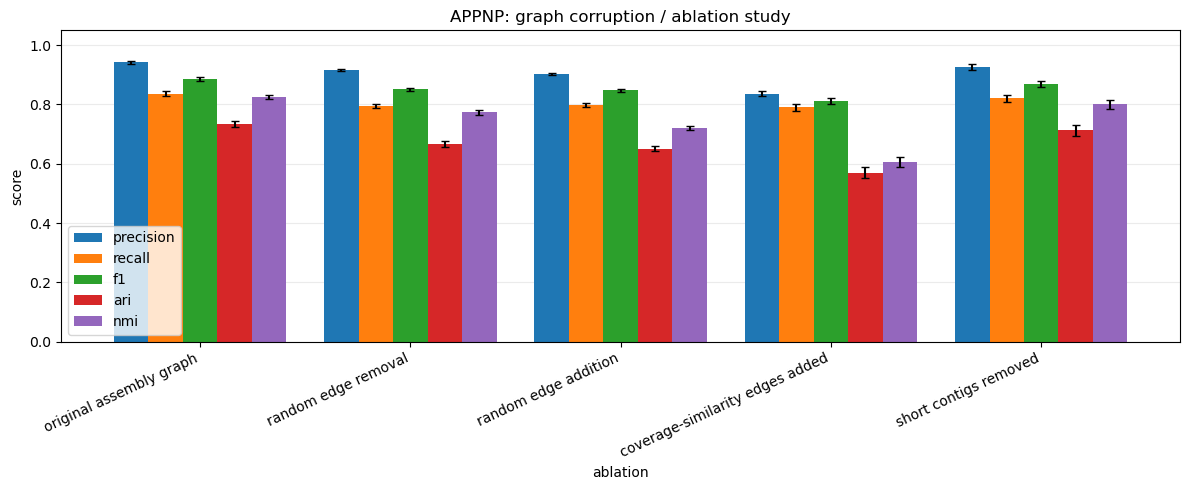

In [6]:
def run_once_ablation(seed, ablation_data):
    global features, adjacency, marker_pairs, labels, label_names, N_CLUSTERS, spectral_embeddings

    old_state = {
        'features': features,
        'adjacency': adjacency,
        'marker_pairs': marker_pairs,
        'labels': labels,
        'label_names': label_names,
        'N_CLUSTERS': N_CLUSTERS,
        'spectral_embeddings': globals().get('spectral_embeddings', None),
    }
    try:
        features = ablation_data['features']
        adjacency = ablation_data['adjacency']
        marker_pairs = ablation_data['marker_pairs']
        labels = ablation_data['labels']
        label_names = ablation_data['label_names']
        N_CLUSTERS = ablation_data['marker_cluster_count']

        # The Laplacian Eigenmaps notebook precomputes graph embeddings outside
        # run_once, so recompute them when the graph changes.
        if 'laplacian_eigenmap_embeddings' in globals():
            spectral_embeddings = laplacian_eigenmap_embeddings(adjacency, dimensions=32)

        return run_once(seed)
    finally:
        features = old_state['features']
        adjacency = old_state['adjacency']
        marker_pairs = old_state['marker_pairs']
        labels = old_state['labels']
        label_names = old_state['label_names']
        N_CLUSTERS = old_state['N_CLUSTERS']
        if old_state['spectral_embeddings'] is not None:
            spectral_embeddings = old_state['spectral_embeddings']

ablation_results, ablation_summary = run_graph_ablation_study(
    data,
    run_once_ablation,
    n_runs=N_RUNS,
    seed=SEED,
)

display(ablation_results)
display(ablation_summary)
plot_ablation_metric_bars(ablation_summary, title=f'{METHOD_NAME}: graph corruption / ablation study')
